In [1]:
import os
import typing
import pandas as pd
import numpy as np
import spacy
from pprint import pprint

In [2]:
import json

with open('/home/mkeber/syn-bioner/bioNER/data/ncbi/trf/syntax_features/syntax_features_sent_tree_head.json', 'r') as file:
    data = json.load(file)


In [3]:
# data = data[:10]
# pprint(data[0])

In [4]:
import networkx as nx

def build_dependency_graphs(data, use_root=True):
    """
    Build NetworkX dependency graphs from dataset entries.

    Args:
        data (list[dict]): list of dependency-parsed sentence dicts.
        use_root (bool): if True, add an explicit root node (id='ROOT_<sent_id>').

    Returns:
        dict[int, nx.DiGraph]: mapping from sentence ID to its NetworkX graph.
    """
    graphs = {}

    for entry in data:
        sent_id = entry["id"]
        sentence = entry["sentence"]
        pos_tags = entry["pos"]
        dep_labels = entry["dep"]
        parents = entry["parents"]

        # Create directed dependency graph
        G = nx.DiGraph(id=sent_id, sentence=sentence)

        n = len(pos_tags)
        root_name = 0

        # Optionally add a synthetic root node
        if use_root:
            G.add_node(root_name, word="ROOT", feature="ROOT", is_root=True)

        # Add nodes (tokens)
        for i in range(1,n+1):
            G.add_node(i, feature=pos_tags[i-1], is_root=False)

        # Add edges (parent -> child)
        for child, parent in enumerate(parents):
            # print(f"child: {child}, parent: {parent}")
            if parent == 0:
                if use_root:
                    # link root node → child
                    # G.add_edge(pos_tags[child], root_name, dep=dep_labels[child])
                    G.add_edge(child+1, root_name, dep=dep_labels[child])
                    
            else:
                # parent index is 1-based, so subtract 1 for zero-based node index
                # parent_idx = parent - 1
                if 0 <= parent < n and use_root:
                    G.add_edge(child+1, parent, dep=dep_labels[child])
                elif 0 <= parent < n:
                    G.add_edge(child+1, parent-1, dep=dep_labels[child])

        graphs[sent_id] = G

    return graphs


# Example usage:
graphs = build_dependency_graphs(data, use_root=True)

# Inspect one example
example_id = 1
G = graphs[example_id]

# print(f"Sentence {example_id}: {G.graph['sentence']}")
# print("Nodes:")
# for node, attrs in G.nodes(data=True):
#     print(f"  {node}: {attrs}")

# print("\nEdges:")
# for u, v, attrs in G.edges(data=True):
#     print(f"  {u} -> {v}: {attrs}")
# print("\n"
#       "-----------------------------------\n"
#       )
# pprint(data[0])

In [5]:
from karateclub import FeatherGraph

/home/mkeber/conda/envs/synBioner/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from karateclub import Graph2Vec
model = Graph2Vec(wl_iterations=2, dimensions=16, attributed=True, workers=24, epochs=40, min_count=5, learning_rate=0.1)
model.fit(list(graphs.values()))
embeddings = model.get_embedding()

Probli smo: wl_iterations više nije bolje

learning_rate oko 0.1 default nije dobar

epochs oko 20 epoha

Pomaže ako uključimo atribute zapravo imena čvorova. 


In [7]:
embeddings.shape
corpus = [d.get("corpus") for d in data]

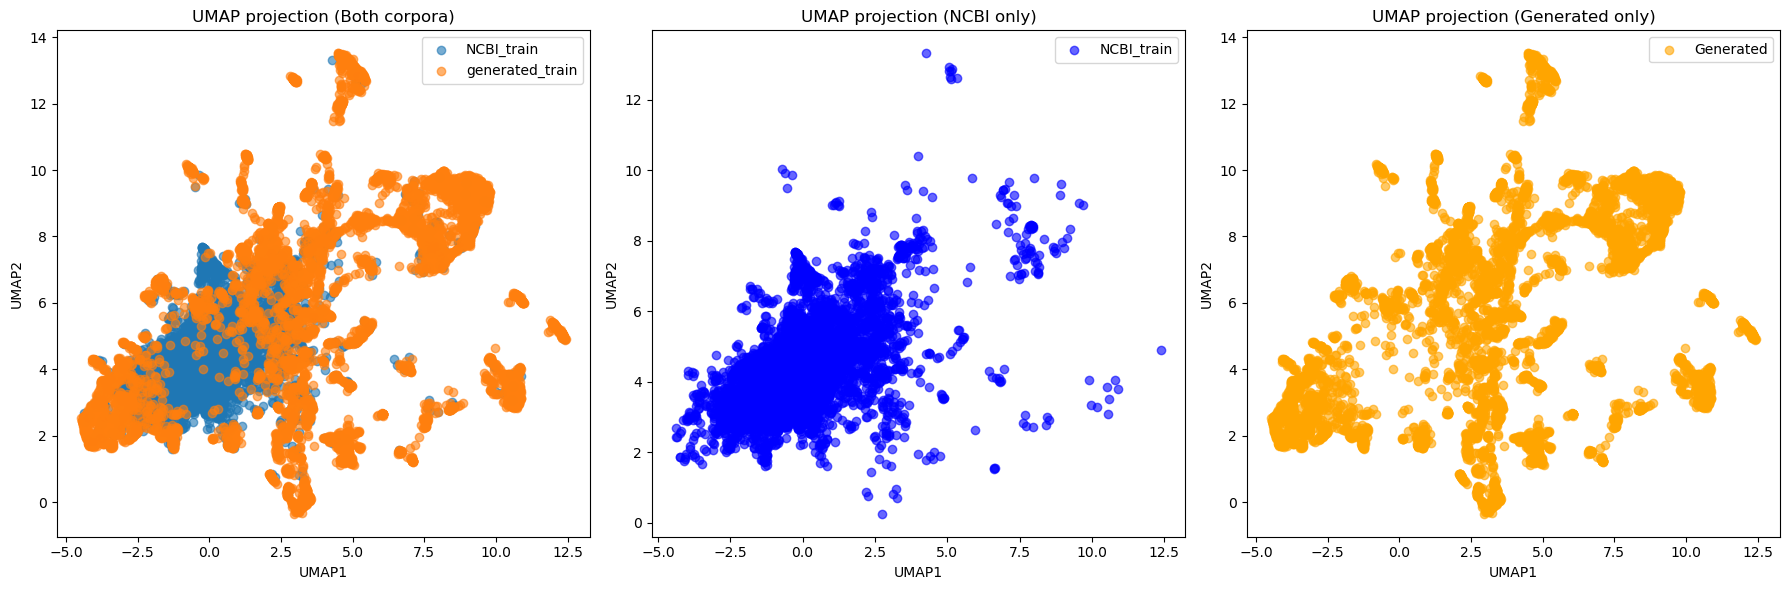

In [8]:
import umap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=25,        # similar to t-SNE perplexity
    min_dist=0.1,          # controls cluster tightness
    metric="cosine",       # works well for text features
    # random_state=42,
    n_jobs=48,
)

X_umap = umap_model.fit_transform(embeddings)

# Save model for later reuse
# joblib.dump(umap_model, "syntax_umap.pkl")

df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df["corpus"] = corpus

df_ncbi = df[df["corpus"] == "NCBI_train"]
df_gen = df[df["corpus"] == "generated_train"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Both datasets ---
ax = axes[0]
for corpus_name, group in df.groupby("corpus"):
    ax.scatter(group["UMAP1"], group["UMAP2"], alpha=0.6, label=corpus_name)
ax.legend()
ax.set_title("UMAP projection (Both corpora)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

# --- 2. NCBI only ---
bx = axes[1]
bx.scatter(df_ncbi["UMAP1"], df_ncbi["UMAP2"], alpha=0.6, color="blue", label="NCBI_train")
bx.legend()
bx.set_title("UMAP projection (NCBI only)")
bx.set_xlabel("UMAP1")
bx.set_ylabel("UMAP2")

# --- 3. Generated only ---
cx = axes[2]
cx.scatter(df_gen["UMAP1"], df_gen["UMAP2"], alpha=0.6, color="orange", label="Generated")
cx.legend()
cx.set_title("UMAP projection (Generated only)")
cx.set_xlabel("UMAP1")
cx.set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

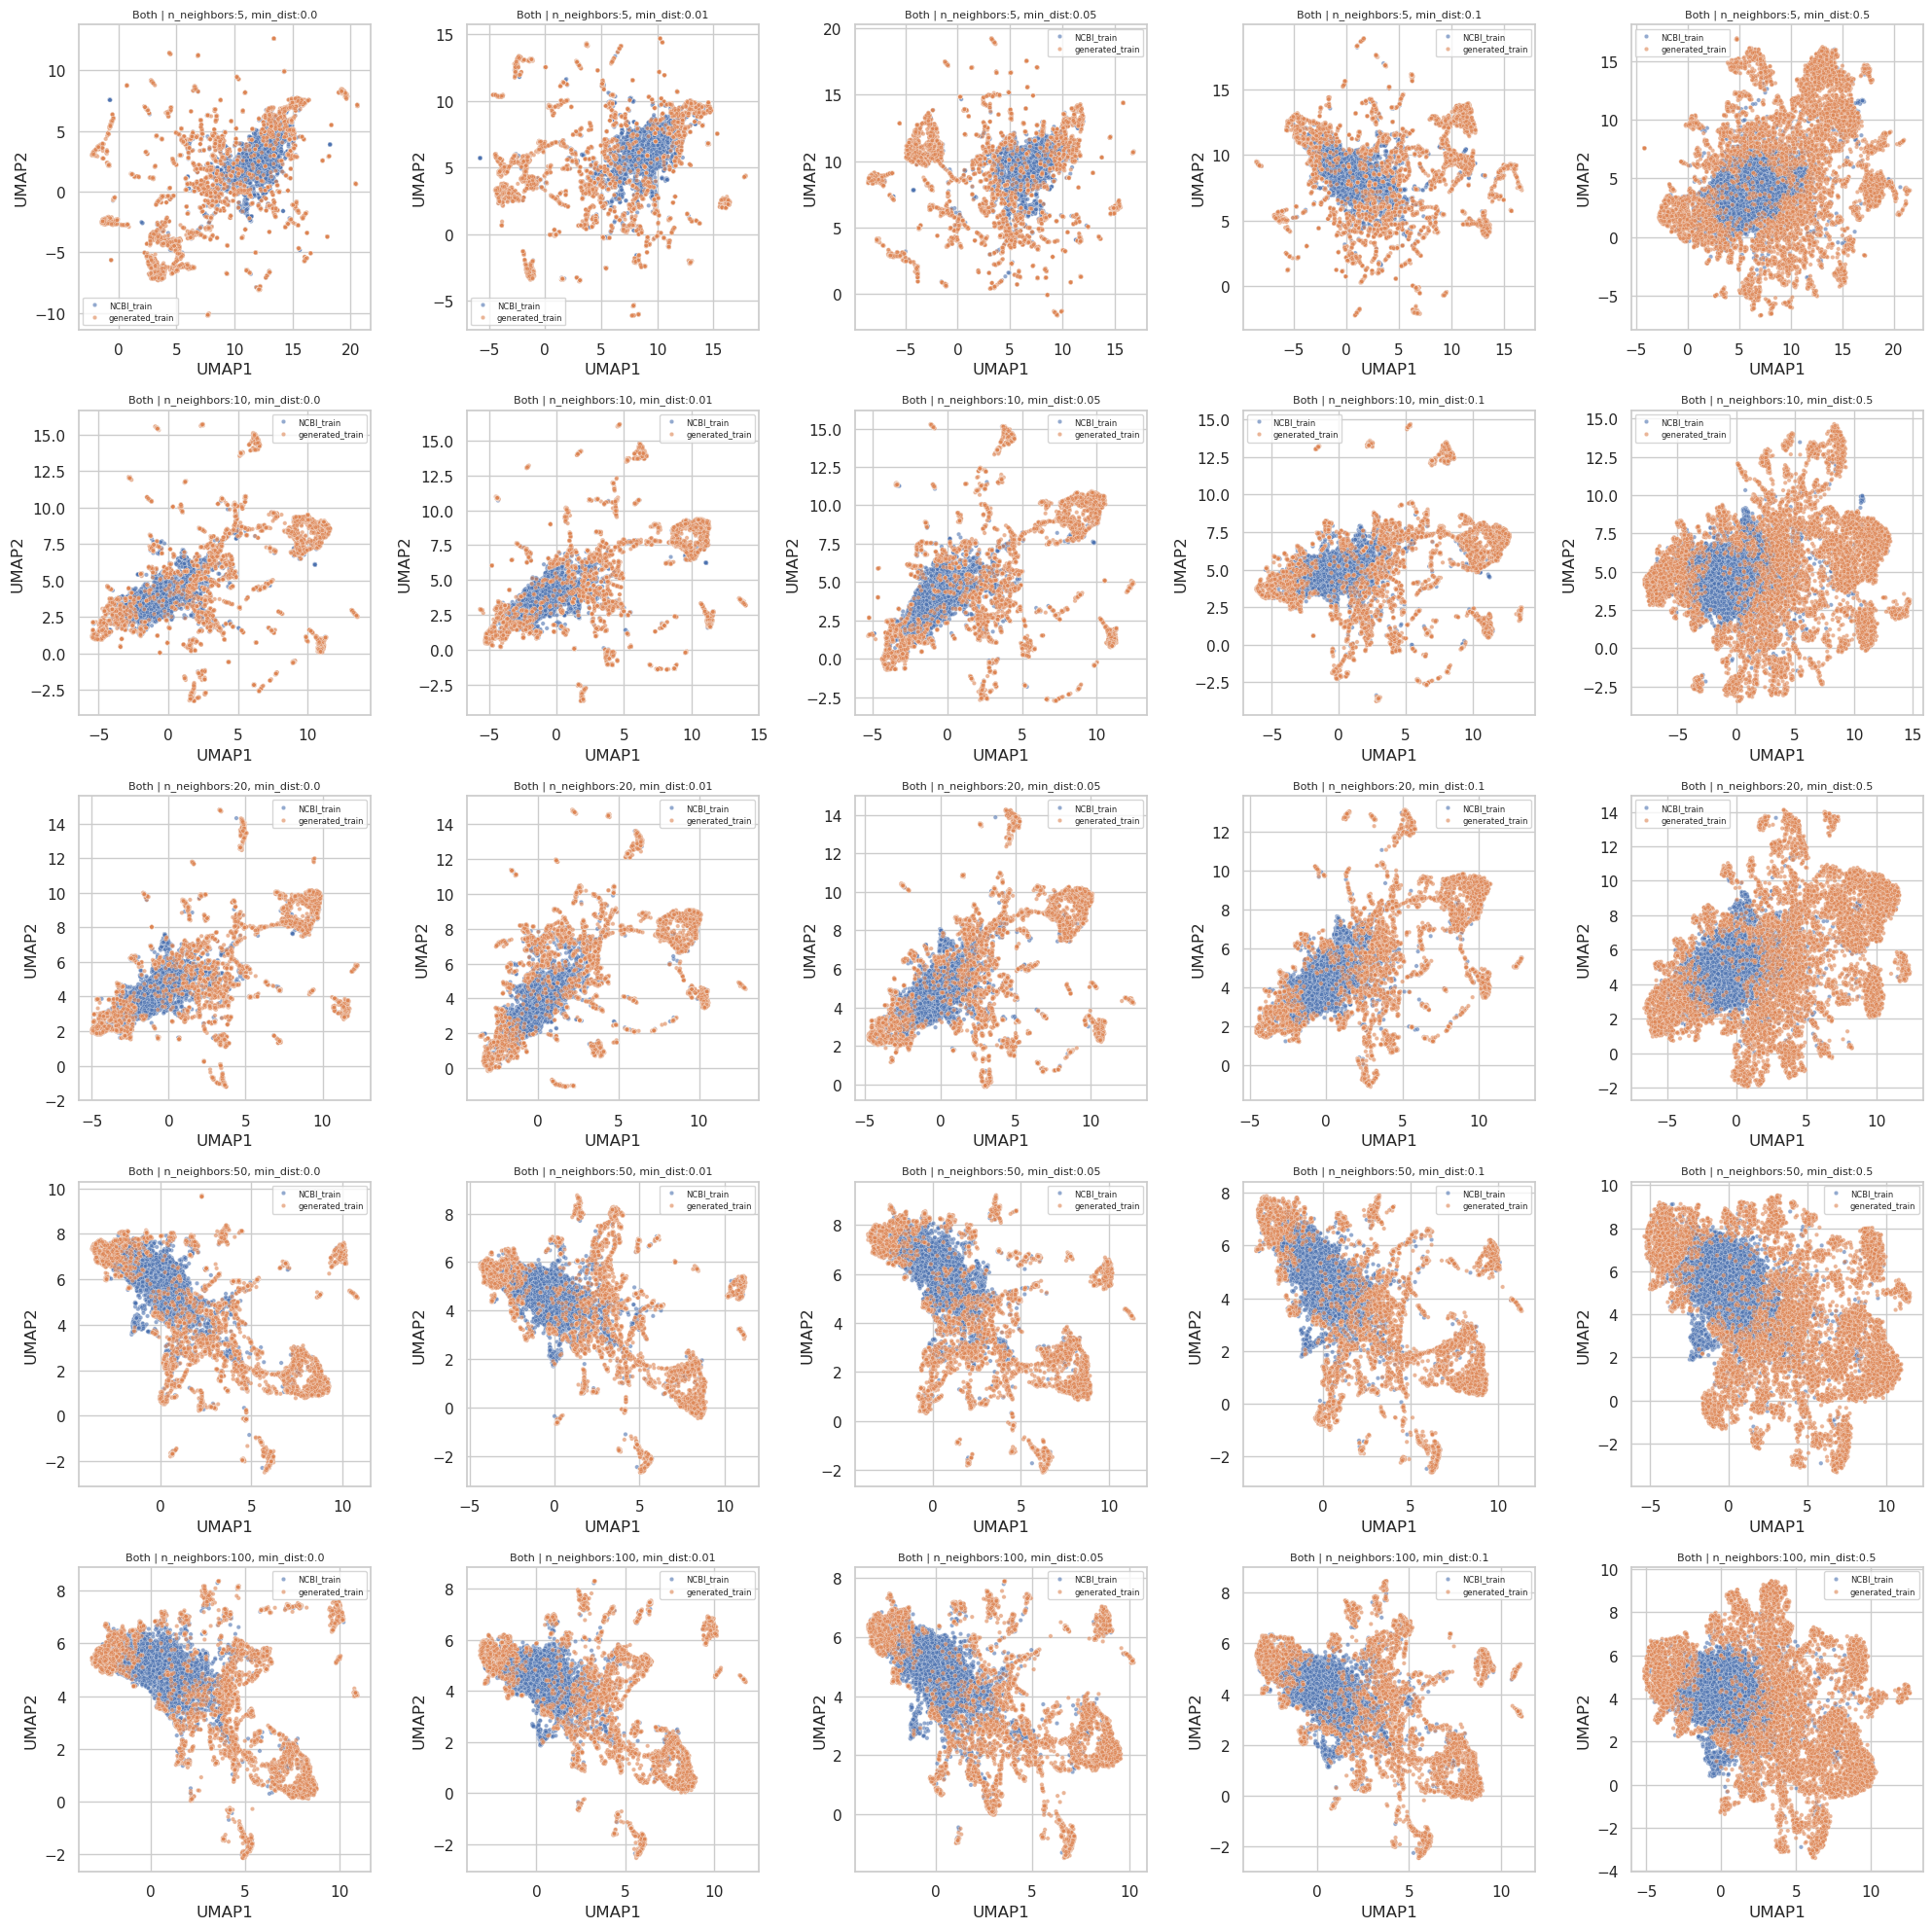

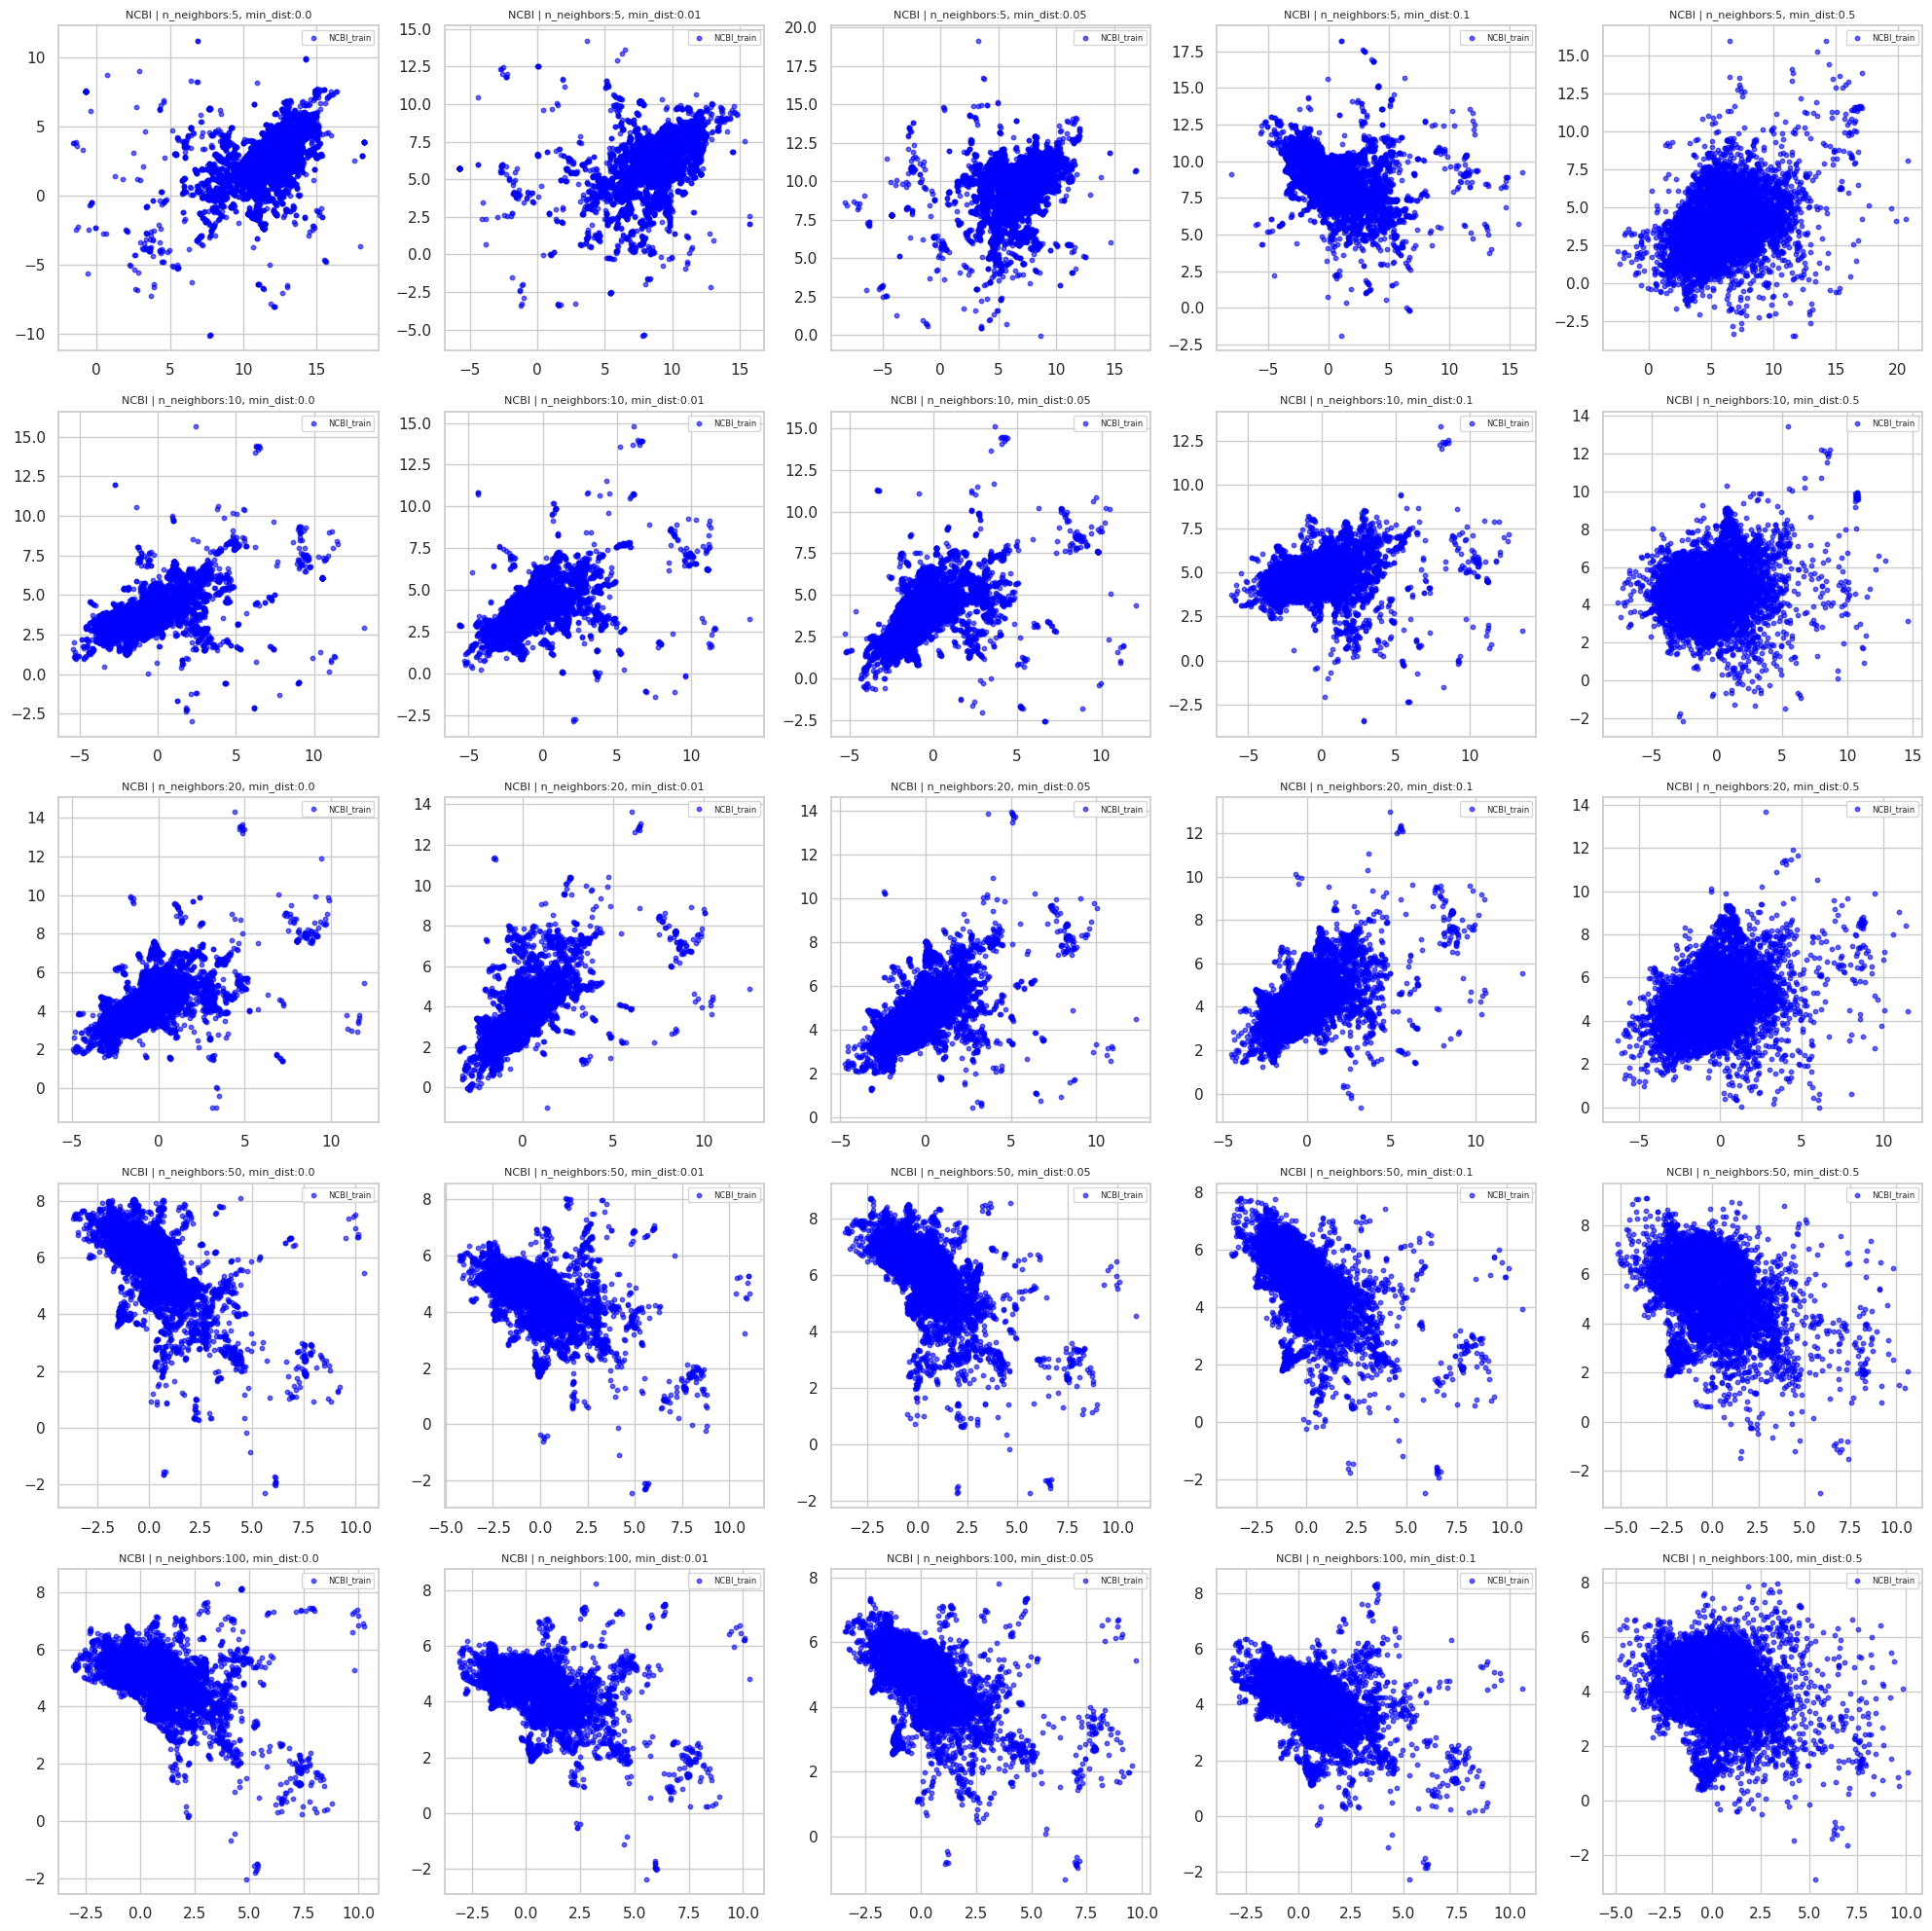

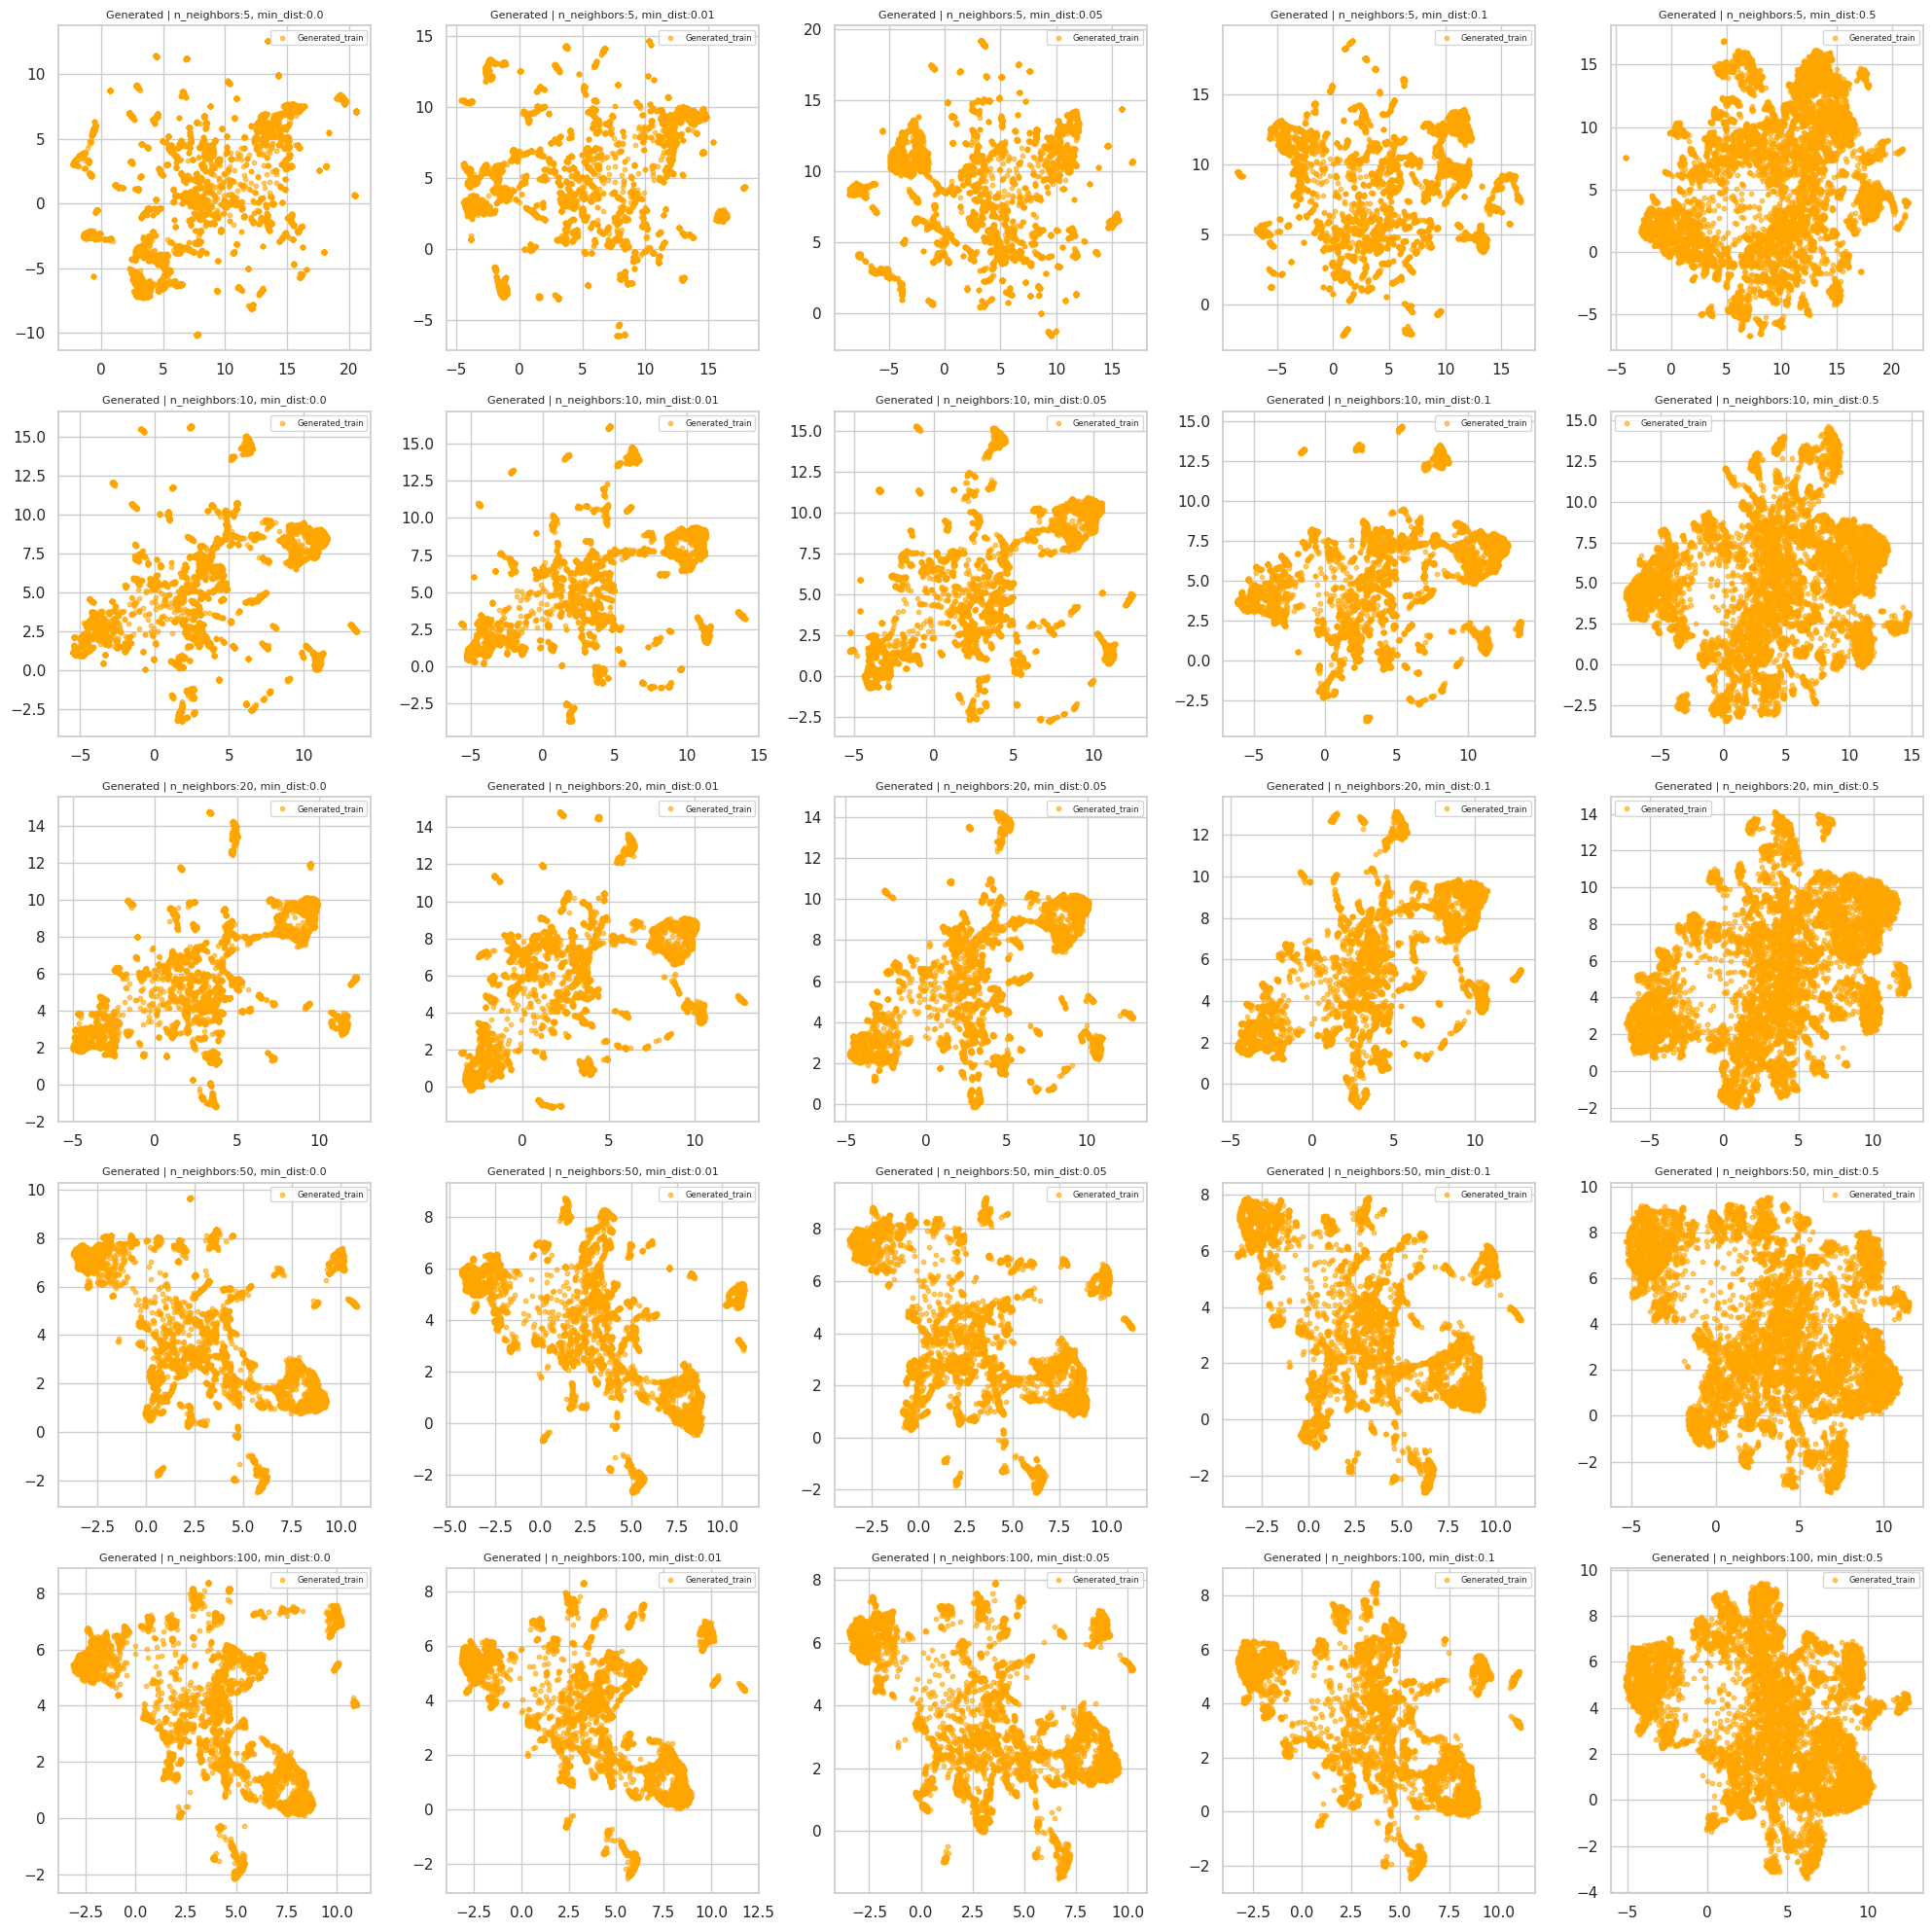

In [9]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

neighbors = [5, 10, 20, 50, 100]
min_dists = [0.0, 0.01, 0.05, 0.1, 0.5]

n_rows = len(neighbors)
n_cols = len(min_dists)

fig_all, axes_all = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
fig_ncbi, axes_ncbi = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
fig_gen, axes_gen = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

axes_all = axes_all.flatten()
axes_ncbi = axes_ncbi.flatten()
axes_gen = axes_gen.flatten()

# silhouette_results = []

# # Divide by corpus
# pos_texts_NCBI = [" ".join(d["pos"]) for d in data if d["corpus"] == "NCBI_train"]
# dep_texts_NCBI = [" ".join(d["dep"]) for d in data if d["corpus"] == "NCBI_train"]

# X_scaled_NCBI, _, _ = vectorize_and_scale(pos_texts_NCBI, dep_texts_NCBI)

# pos_texts_gen = [" ".join(d["pos"]) for d in data if d["corpus"] == "generated_train"]
# dep_texts_gen = [" ".join(d["dep"]) for d in data if d["corpus"] == "generated_train"]

# X_scaled_gen, _, _ = vectorize_and_scale(pos_texts_gen, dep_texts_gen)

# --- Iterate over grid ---
for i, n_neighbors in enumerate(neighbors):
    for j, min_dist in enumerate(min_dists):
        # Calculate the linear index for the flattened arrays
        linear_index = i * n_cols + j

        umap_model = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,        # similar to t-SNE perplexity
            min_dist=min_dist,          # controls cluster tightness
            metric="cosine",       # works well for text features
            # random_state=42,
            n_jobs=48,
        )

        umap_fit = umap_model.fit_transform(embeddings)
        # X_umap_NCBI = umap_fit.transform(embeddings)
        # X_umap_gen = umap_fit.transform(embeddings)

        df = pd.DataFrame(umap_fit, columns=["UMAP1", "UMAP2"])
        df["corpus"] = corpus

        df_ncbi = df[df["corpus"] == "NCBI_train"]
        df_gen = df[df["corpus"] == "generated_train"]

        # Select subplot axes
        ax = axes_all[linear_index]
        bx = axes_ncbi[linear_index]
        cx = axes_gen[linear_index]

        # --- Plot both datasets ---
        sns.scatterplot(data=df, x="UMAP1", y="UMAP2", hue="corpus", ax=ax, alpha=0.6, s=10)
        ax.set_title(f"Both | n_neighbors:{n_neighbors}, min_dist:{min_dist}", fontsize=8)
        ax.legend(fontsize=6)

        # --- Plot only NCBI ---
        bx.scatter(df_ncbi["UMAP1"], df_ncbi["UMAP2"], alpha=0.6, color="blue", label="NCBI_train", s=10)
        bx.set_title(f"NCBI | n_neighbors:{n_neighbors}, min_dist:{min_dist}", fontsize=8)
        bx.legend(fontsize=6)

        # --- Plot only Generated ---
        cx.scatter(df_gen["UMAP1"], df_gen["UMAP2"], alpha=0.6, color="orange", label="Generated_train", s=10)
        cx.set_title(f"Generated | n_neighbors:{n_neighbors}, min_dist:{min_dist}", fontsize=8)
        cx.legend(fontsize=6)

# Adjust spacing
for fig in [fig_all, fig_ncbi, fig_gen]:
    fig.tight_layout()

plt.show()


fig_all.savefig("umap_both_grid.png", dpi=300)
fig_ncbi.savefig("umap_ncbi_grid.png", dpi=300)
fig_gen.savefig("umap_generated_grid.png", dpi=300)